In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Optional for Jupyter users
# %matplotlib inline

# 1. Import the dataset (FIXED path issue)
df = pd.read_csv("C:/Users/Sugil/Downloads/Ecommerce_Delivery_Analytics_New.csv")

In [3]:
# 2. Get info about the dataset
print("\n--- Dataset Info ---")
df.info()
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Order ID                 100000 non-null  str  
 1   Customer ID              100000 non-null  str  
 2   Platform                 100000 non-null  str  
 3   Order Date & Time        100000 non-null  str  
 4   Delivery Time (Minutes)  100000 non-null  int64
 5   Product Category         100000 non-null  str  
 6   Order Value (INR)        100000 non-null  int64
 7   Customer Feedback        100000 non-null  str  
 8   Service Rating           100000 non-null  int64
 9   Delivery Delay           100000 non-null  str  
 10  Refund Requested         100000 non-null  str  
dtypes: int64(3), str(8)
memory usage: 8.4 MB

--- Summary Statistics ---
         Order ID Customer ID          Platform Order Date & Time  \
count      100000      100000            100000

In [4]:
# 3. Handling Missing Data
print("\n--- Missing Values ---")
print(df.isnull().sum())  # Check for null values


--- Missing Values ---
Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64


In [5]:
# Convert datetime column (FIXED coercion issue)
df['Order Date & Time'] = pd.to_datetime(df['Order Date & Time'], errors='coerce')
df = df.dropna(subset=['Order Date & Time'])  # Drop rows with invalid date

C:\Users\Sugil\AppData\Local\Temp\ipykernel_15072\2149681419.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date & Time'] = pd.to_datetime(df['Order Date & Time'], errors='coerce')


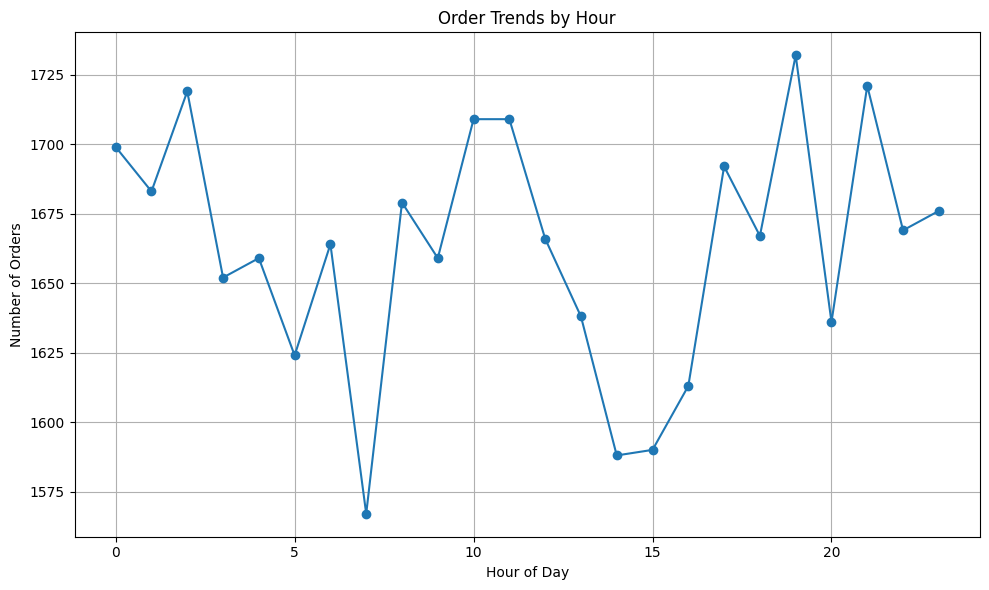

In [6]:
# Objective 1: Order Trends & Peak Hours Analysis
df['Hour'] = df['Order Date & Time'].dt.hour
order_trends = df['Hour'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
order_trends.plot(kind='line', marker='o')
plt.title('Order Trends by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.tight_layout()
plt.show()

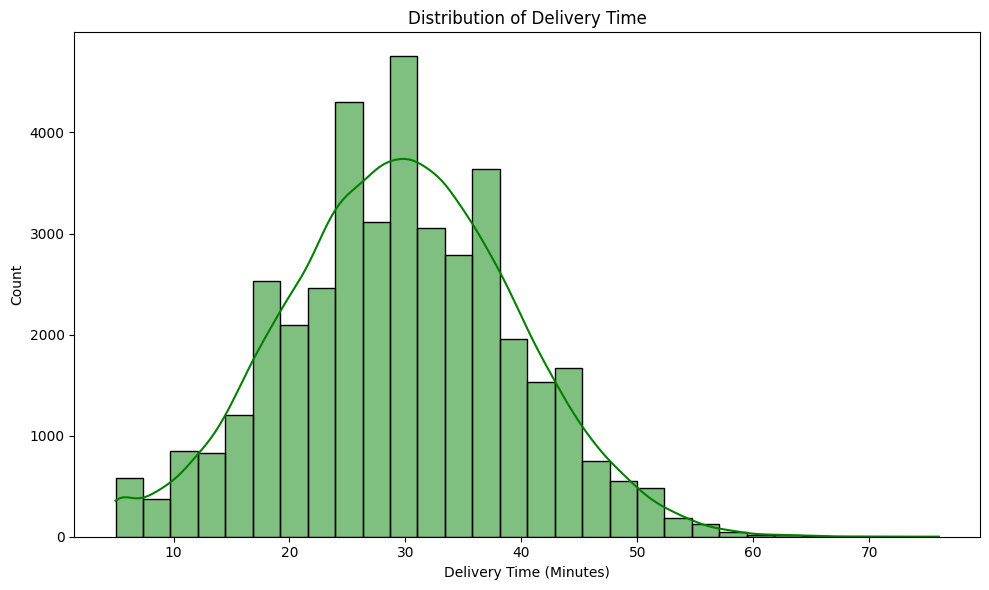

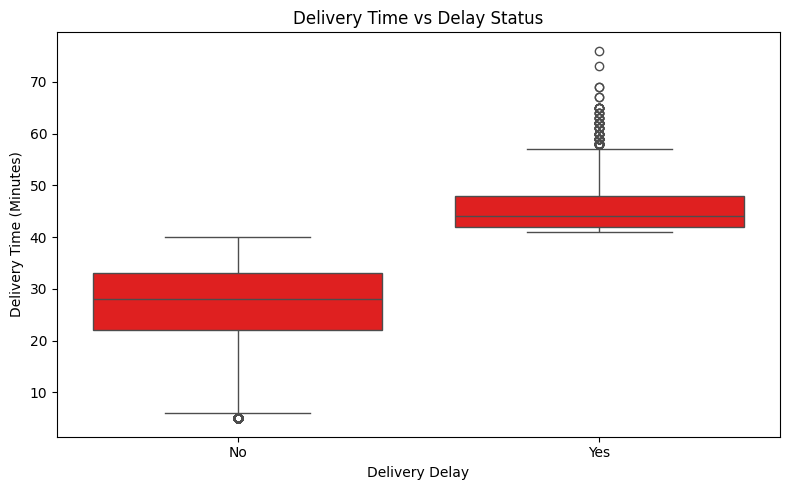

In [7]:
# Objective 2: Delivery Time Analysis & Delay Impact
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery Time (Minutes)'], bins=30, kde=True,color="green")
plt.title('Distribution of Delivery Time')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Delivery Delay', y='Delivery Time (Minutes)',color="red")
plt.title('Delivery Time vs Delay Status')
plt.tight_layout()
plt.show()

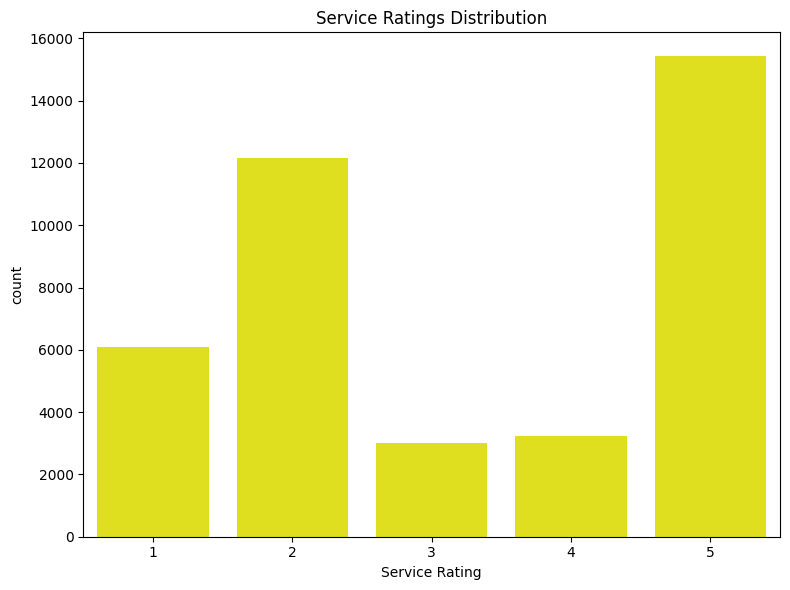

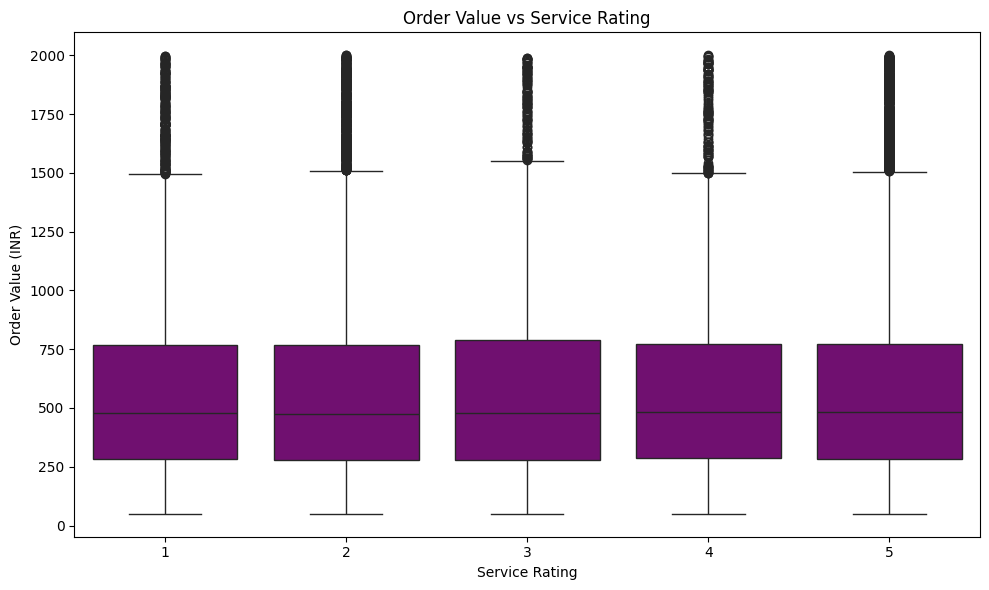

In [8]:
# Objective 3: Customer Satisfaction & Service Ratings
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Service Rating',color="yellow")
plt.title('Service Ratings Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Service Rating', y='Order Value (INR)',color="purple")
plt.title('Order Value vs Service Rating')
plt.tight_layout()
plt.show()

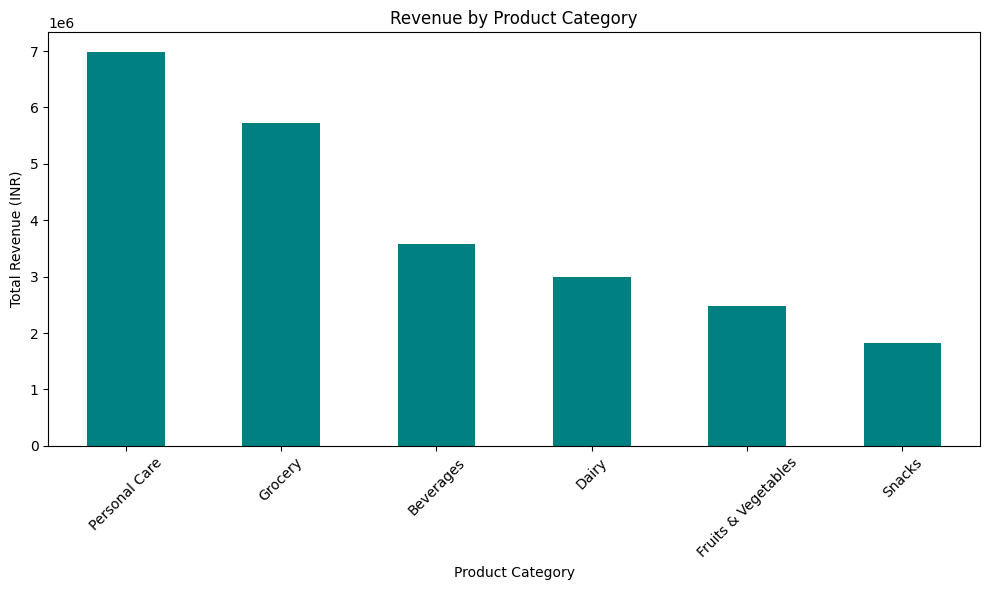

In [9]:
# Objective 4: Revenue Insights & Top-Selling Products
product_revenue = df.groupby('Product Category')['Order Value (INR)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
product_revenue.plot(kind='bar', color='teal')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

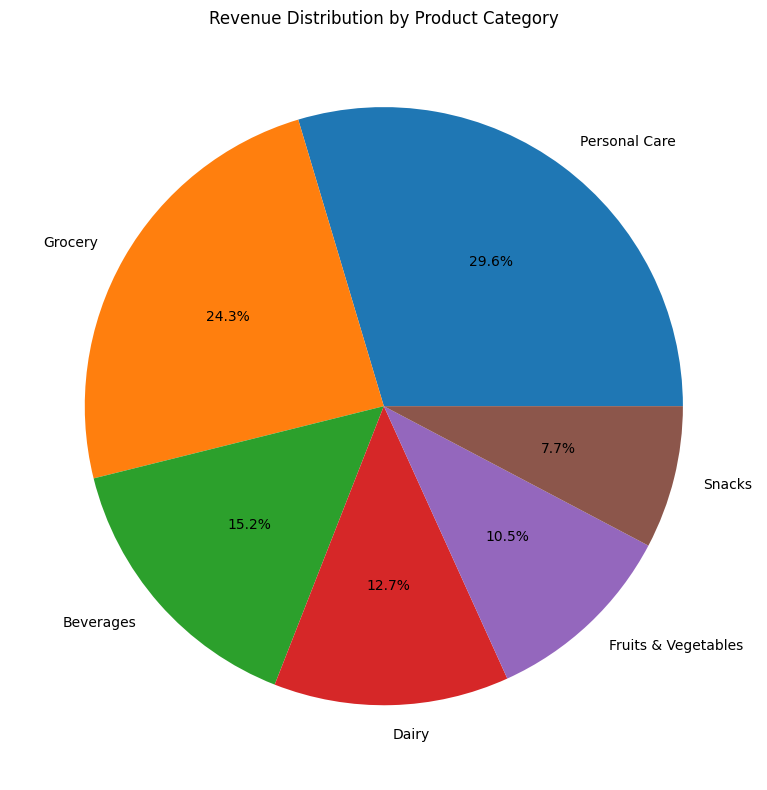

In [10]:
# Pie chart
plt.figure(figsize=(8, 8))
product_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Revenue Distribution by Product Category')
plt.tight_layout()
plt.show()

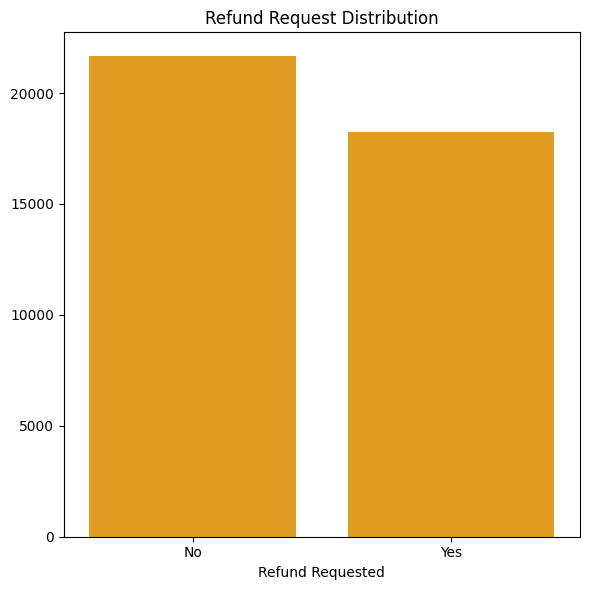

In [11]:
# Objective 5: Refund & Complaint Analysis
refund_counts = df['Refund Requested'].value_counts()
plt.figure(figsize=(6, 6))
sns.barplot(x=refund_counts.index, y=refund_counts.values,color="orange")
plt.title('Refund Request Distribution')
plt.tight_layout()
plt.show()

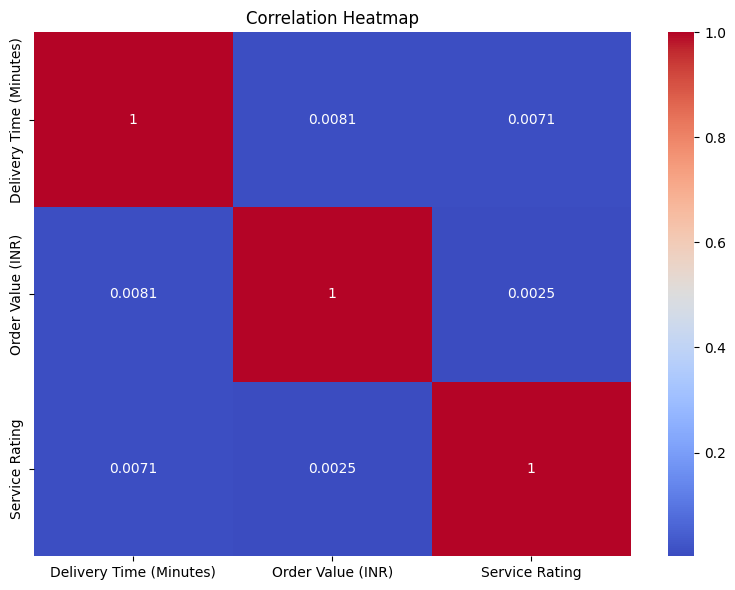

In [12]:
# 6. Heatmap of correlations
corr = df[['Delivery Time (Minutes)', 'Order Value (INR)', 'Service Rating']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
# 7. Outliers - Z-Score
z_scores = np.abs(zscore(df[['Delivery Time (Minutes)', 'Order Value (INR)']]))
outliers = (z_scores > 3)
print("\n--- Number of Outliers (z > 3) ---")
print(outliers.sum())


--- Number of Outliers (z > 3) ---
591


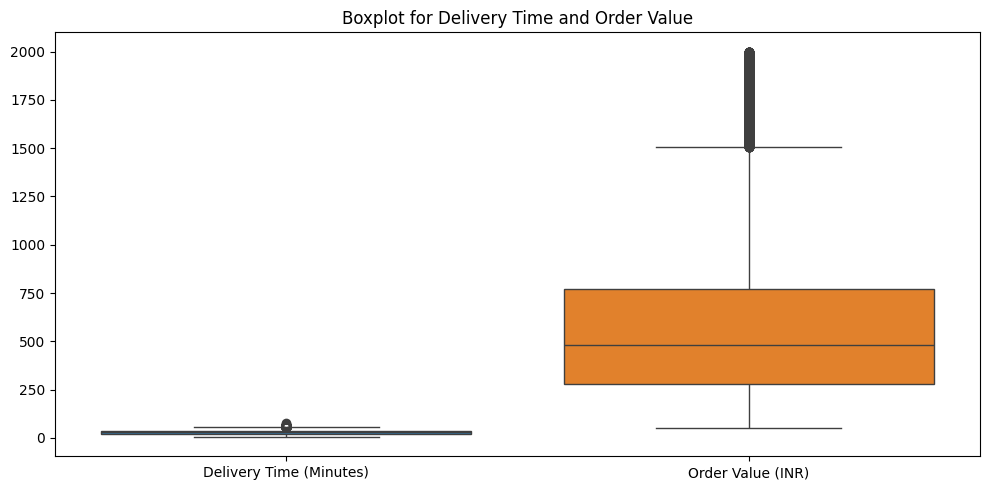

In [14]:
# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Delivery Time (Minutes)', 'Order Value (INR)']])
plt.title('Boxplot for Delivery Time and Order Value')
plt.tight_layout()
plt.show()

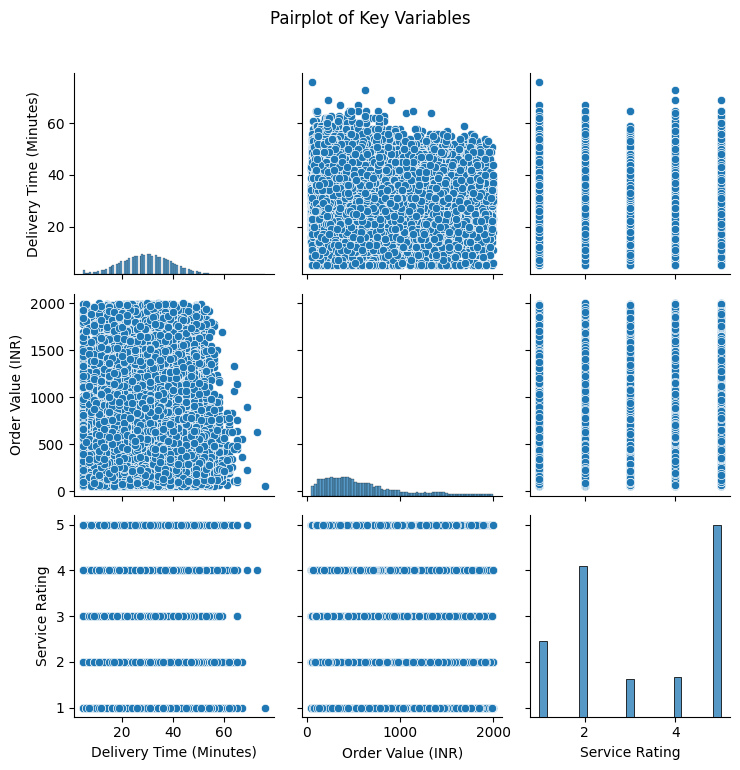

In [15]:
# Pairplot
sns.pairplot(df[['Delivery Time (Minutes)', 'Order Value (INR)', 'Service Rating']])
plt.suptitle('Pairplot of Key Variables', y=1.02)
plt.tight_layout()
plt.show()

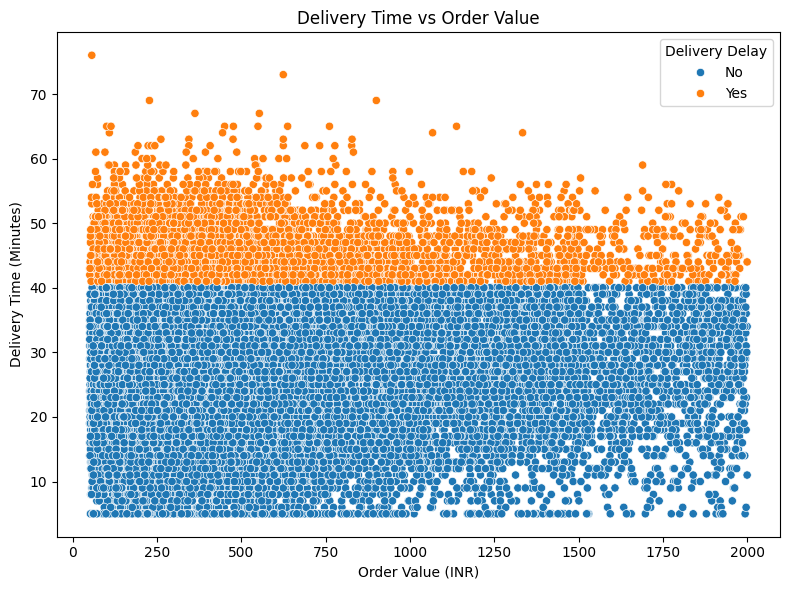

In [16]:
# Scatter plot: Delivery Time vs Order Value
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Order Value (INR)', y='Delivery Time (Minutes)', hue='Delivery Delay')
plt.title('Delivery Time vs Order Value')
plt.tight_layout()
plt.show()